# Fig. 4 — behavioral x neural cross-measure correlations

Reworked from `thesis_ch-DD-neuro_01.ipynb`
(`cross_measure_partial_r2_behav-neural_group-removed.pdf`) into the paper house style.

Differences from the thesis version:

- **Gradient measures dropped** (`NPC_dispersion`, `grad_std`) and **aggregate IQ dropped**
  (`mean_iq` — its two subscores `me`/`kn` are already in the matrix, so the mean is a
  linear combination of rows that are shown anyway).
- **|ρ| instead of ρ²** in the cells. r² reads as "variance explained", but it squashes
  everything below r ≈ 0.4 into visually indistinguishable near-zero cells; the absolute
  correlation keeps the same 0-1 unsigned scale while spreading the actual range out.
  The printed coefficient keeps its sign; only the shading is unsigned.
- **Two independent controls**, set in the config cell below: partialling out group, and
  correcting for multiple comparisons. Either, both, or neither.
- **Scatter panels** for whichever pairs survive, so the matrix can be checked against
  what the raw data actually look like.

The two parts are drawn by `draw_heatmap()` / `draw_scatter()`, which take an `ax`, so the
standalone exports and the combined Fig. 4 are the same code rather than two drifting
copies.

Runs on the Mac with the `behav_fit` env (needs `numrisk` + `pingouin`).

In [1]:
import os
import os.path as op
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sys.path.insert(0, '/Users/mrenke/git')
from parietal_patterns.prep_results.plotting import (
    set_style, format_pvalue, add_panel_letter_fig, wrap_label,
    GROUP_LABELS, GROUP_ORDER, GROUP_PALETTE)
from parietal_patterns.utils.statistics import sig_stars

set_style()

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


## Config

The two controls are independent switches, so all four combinations are reachable:

| `CONTROL_GROUP_VARIANCE` | `CORRECT_MULTIPLE_COMPARISONS` | what the matrix shows |
|---|---|---|
| `False` | `False` | raw Spearman ρ, uncorrected stars |
| `True`  | `False` | group partialled out, uncorrected stars (= the thesis figure) |
| `False` | `True`  | raw Spearman ρ, FDR-corrected stars |
| `True`  | `True`  | both |

Only the **stars** respond to `CORRECT_MULTIPLE_COMPARISONS` — the correction changes which
p-values survive, not the correlations themselves, so the shading is identical between the
two right-hand rows above. `CONTROL_GROUP_VARIANCE` changes both.

In [2]:
CONTROL_GROUP_VARIANCE = True        # partial out DD-vs-control from every pair
CORRECT_MULTIPLE_COMPARISONS = True  # stars from corrected p instead of raw p
MC_METHOD = 'fdr_bh'                 # correction family, over all cells of the matrix

MIN_N = 10   # a pair with fewer complete cases than this is left blank
VMAX = 0.5   # top of the |rho| colour scale

BIDS_ROOT = '/Users/mrenke/data/ds-dnumrisk'
PHENOTYPE_DIR = op.join(BIDS_ROOT, 'derivatives', 'phenotype')
OUT_DIRS = ['/Users/mrenke/Desktop/DNumRisk/figures/paperFigs_DD_03',
            '/Users/mrenke/obsidian-wiki/dyscalc_paper_rework/figures/plots']
for d in OUT_DIRS:
    os.makedirs(d, exist_ok=True)

## Measures

Behaviour: the three PMC-RDM noise-dissociation parameters from the magnitude-judgement
task (`t0` excluded, as in the thesis notebook) plus the standardized cognitive tests
(no questionnaires, no raw accuracy/RT, no probit params), minus `mean_iq`.

Neural: nPRF decodability and mean R², PFM network area inside the NPC mask (the two
networks present in every subject), and the two DAN patches that differed between groups.

In [3]:
from numrisk.behavior_general.measures_registry import (
    load_all, _load_magjudge_bauer, _load_decode_r, _load_npc_pfm_net_area)

group_df = pd.read_csv(op.join(BIDS_ROOT, 'group_assignment.csv')).set_index('subject')

behav_pmc_rdm = _load_magjudge_bauer(variant='v4_rdm', suffix_columns=False).drop(columns=['t0'])
behav_cognitive, _ = load_all(include_categories=['behavioral_cognitive'])

nPRF_r = _load_decode_r()
nPRF_r2 = pd.read_csv(op.join(PHENOTYPE_DIR, 'nPRF_r2area.csv')).set_index('subject')[['mean_R2']]
npc_pfm_sel = _load_npc_pfm_net_area()[['Visual2_size', 'Dorsal-attention_size']]
patch_wide = (pd.read_csv(op.join(PHENOTYPE_DIR, 'netsPFM_DANpatches_refAtlas-caNets_DDnr.csv'))
              .rename(columns={'sub_id': 'subject'})
              .set_index(['subject', 'patch'])['ind_area'].unstack('patch'))
dan_patches_sel = patch_wide[['R_parietal-lateral', 'L_frontal-lateral']]

df_bn = (behav_pmc_rdm
         .join(behav_cognitive, how='outer')
         .join(nPRF_r, how='outer')
         .join(nPRF_r2, how='outer')
         .join(npc_pfm_sel, how='outer')
         .join(dan_patches_sel, how='outer')
         .join(group_df[['group']], how='inner'))

# mean_iq dropped: it is the average of `me` and `kn`, both of which are rows already
DROP_BEHAV = ['mean_iq']
behav_vars = [c for c in list(behav_pmc_rdm.columns) + list(behav_cognitive.columns)
              if c not in DROP_BEHAV]
# gradient measures (NPC_dispersion, grad_std) deliberately not in this list.
# PFM block ordered so the two DAN measures sit next to each other: the NPC-mask DAN
# area and the R parietal-lateral patch are the same network at two grains, and reading
# them adjacently is the point of having both
neural_vars = ['neural_numsense_precision', 'mean_R2',
               'Visual2_size', 'Dorsal-attention_size',
               'R_parietal-lateral', 'L_frontal-lateral']

pretty_names = {
    'perceptual_noise_sd': 'PMC-RDM: Perceptual noise',
    'memory_noise_sd': 'PMC-RDM: Memory noise',
    'a': 'PMC-RDM: Boundary separation ($a$)',
    'me': 'Visuospatial IQ (Matrizen)',
    'kn': 'Verbal IQ (Kategorien nennen)',
    'erfassungsspanne': 'Visuospatial WM (Corsi span)',
    'weber_transformed': 'Weber fraction (log)',
    'skill_score': 'Math skill (DEMAT)',
    'neural_numsense_precision': 'nPRF: Decodability ($r$)',
    'mean_R2': 'nPRF: mean R²',
    'Dorsal-attention_size': 'PFM: DAN area (in NPC mask)',
    'Visual2_size': 'PFM: Visual2 area (in NPC mask)',
    'L_frontal-lateral': 'DAN patch: L frontal-lateral',
    'R_parietal-lateral': 'DAN patch: R parietal-lateral',
}

df_bn[behav_vars + neural_vars].shape

(66, 14)

## Correlations

Spearman throughout. With `CONTROL_GROUP_VARIANCE` the pair is a partial correlation with
`group` as covariate — i.e. how much the two measures track each other *beyond* what both
merely share with the DD-vs-control split.

Each pair uses its own complete cases (`dropna` per cell), so `n` varies across the matrix
and is kept for reporting.

In [4]:
corr = pd.DataFrame(index=behav_vars, columns=neural_vars, dtype=float)
pval = pd.DataFrame(index=behav_vars, columns=neural_vars, dtype=float)
n_obs = pd.DataFrame(index=behav_vars, columns=neural_vars, dtype=float)

for b in behav_vars:
    for nv in neural_vars:
        sub = df_bn[[b, nv, 'group']].dropna()
        if len(sub) < MIN_N:
            continue
        if CONTROL_GROUP_VARIANCE:
            res = pingouin.partial_corr(data=sub, x=b, y=nv, covar='group', method='spearman')
        else:
            res = pingouin.corr(sub[b], sub[nv], method='spearman')
        corr.loc[b, nv] = res['r'].iloc[0]
        pval.loc[b, nv] = res['p-val'].iloc[0]
        n_obs.loc[b, nv] = len(sub)

abs_corr = corr.abs()

In [5]:
def correct_matrix(pval, method=MC_METHOD):
    """Correct every filled cell of the matrix as one family, keeping the 2D shape.

    Flattening is what makes the family the *whole* matrix rather than one row or column:
    with 8 behavioural x 6 neural measures that is ~48 tests, and correcting per row would
    understate the search that actually happened.
    """
    flat = pval.values.ravel()
    filled = ~np.isnan(flat)
    out = np.full_like(flat, np.nan)
    out[filled] = pingouin.multicomp(flat[filled], method=method)[1]
    return pd.DataFrame(out.reshape(pval.shape), index=pval.index, columns=pval.columns)


pval_corrected = correct_matrix(pval)
pval_shown = pval_corrected if CORRECT_MULTIPLE_COMPARISONS else pval

n_tests = int(pval.notna().sum().sum())
print(f'{n_tests} tests | raw p<.05: {int((pval < .05).sum().sum())}'
      f' | {MC_METHOD} p<.05: {int((pval_corrected < .05).sum().sum())}')

# pairs to scatter follow the config rather than being hard-coded
sig_pairs = [(b, nv) for b in behav_vars for nv in neural_vars
             if pd.notna(pval_shown.loc[b, nv]) and pval_shown.loc[b, nv] < 0.05]
print('surviving pairs:', sig_pairs)

48 tests | raw p<.05: 5 | fdr_bh p<.05: 2
surviving pairs: [('perceptual_noise_sd', 'mean_R2'), ('me', 'Dorsal-attention_size')]


## Drawing functions

Both take an `ax`, so the standalone exports below and the combined Fig. 4 further down
draw through the same code.

In [6]:
# r-strings throughout: a bare '\rho' in a normal literal is a carriage return, not mathtext
CBAR_LABEL = (r'|partial Spearman $\rho$|' if CONTROL_GROUP_VARIANCE
              else r'|Spearman $\rho$|')
STAR_NOTE = (f'{MC_METHOD.upper().replace("_", "-")}-corrected'
             if CORRECT_MULTIPLE_COMPARISONS else 'uncorrected')
RHO_SYM = r'\rho_{\mathrm{partial}}' if CONTROL_GROUP_VARIANCE else r'\rho'

sequential_cmap = LinearSegmentedColormap.from_list('purple_seq', ['#f0efec', '#832ad6'])


def draw_heatmap(ax, cbar_ax=None):
    """|rho| heatmap with signed annotations and significance stars."""
    # colour encodes |rho| but the printed number keeps its sign: direction is real
    # information (does more perceptual noise go with *less* nPRF R2?) and there is no
    # reason to throw it away, while a diverging colour scale would spend half its range
    # separating signs instead of separating strengths
    annot_labels = corr.map(lambda v: '' if pd.isna(v) else f'{v:.2f}'.replace('-', '−'))

    sns.heatmap(abs_corr.astype(float), cmap=sequential_cmap, vmin=0, vmax=VMAX,
                square=True, annot=annot_labels.values, fmt='', annot_kws={'size': 8.5},
                linewidths=0.5, linecolor='white', ax=ax,
                cbar=cbar_ax is not None, cbar_ax=cbar_ax,
                cbar_kws={'label': CBAR_LABEL} if cbar_ax is not None else None)

    ax.set_xticklabels([pretty_names.get(c, c) for c in neural_vars], rotation=45,
                       ha='right', fontsize=8)
    # two lines each (wrap_label breaks after 'PMC-RDM:' / before '(Corsi span)'): these
    # labels set the width of the whole left margin, and the combined figure spends that
    # width on the scatter column instead
    ax.set_yticklabels([wrap_label(pretty_names.get(c, c)) for c in behav_vars],
                       rotation=0, fontsize=8)
    ax.set_xlabel('Neural measures', fontsize=9, labelpad=8)
    ax.set_ylabel('Behavioral / cognitive measures', fontsize=9, labelpad=8)
    ax.tick_params(length=0)

    # stars sit just above the number in the same cell, so shade / value / inference are
    # readable as one unit rather than needing a second lookup.
    # The asterisk glyph sits high in its em box and occupies little of it, so it reads
    # far smaller than its nominal size -- it needs a point size well above the numbers'
    # to look comparable, and va='top' to hang it just under the cell's upper edge
    # rather than leaving the visual gap that va='center' produces.
    for i, b in enumerate(behav_vars):
        for j, nv in enumerate(neural_vars):
            stars = sig_stars(pval_shown.loc[b, nv])
            if stars:
                ax.text(j + 0.5, i + 0.08, stars, ha='center', va='top',
                        fontsize=13, fontweight='bold', color='0.1')

    # title deliberately off -- what it used to say (which controls are active, what the
    # stars mean) belongs in the caption, and repeating it above the panel wastes the
    # vertical space that the combined figure needs. Re-enable for a quick standalone look:
    # ax.set_title(f'Behavior $\\times$ neural cross-measure correlations\n'
    #              f'{"group effect removed, " if CONTROL_GROUP_VARIANCE else ""}'
    #              f'stars {STAR_NOTE}', fontsize=9, pad=10)
    return ax


# View-only axis limits, per variable: one subject (sub-46, perceptual noise 1.09 vs. a
# median of 0.39 and a next-highest of 0.79) stretches the axis so far that the rest of
# the sample collapses into a band. Clipping the *view* spreads the bulk out again.
# This changes nothing about the statistics or the fitted line -- both still use all
# subjects, the outlier included -- so the panel must be captioned as showing an
# off-scale point, not as excluding one.
AXIS_CLIP = {'perceptual_noise_sd': (None, 0.85)}


def apply_clip(ax, var, axis):
    """Apply an AXIS_CLIP entry to whichever axis the variable was plotted on.

    Returns how many subjects now fall outside the view, so a clipped panel can never
    silently drop a point without it being reported.
    """
    if var not in AXIS_CLIP:
        return 0
    lo, hi = AXIS_CLIP[var]
    if axis == 'y':
        ax.set_ylim(bottom=lo, top=hi)
    else:
        ax.set_xlim(left=lo, right=hi)

    series = df_bn[var].dropna()
    n_off = 0
    if hi is not None:
        n_off += int((series > hi).sum())
    if lo is not None:
        n_off += int((series < lo).sum())
    return n_off


# What each surviving pair is *about*, as a heading on the panel: the nPRF/perceptual-noise
# link is within the numerical domain, the DAN/visuospatial-IQ link is not. Keyed by pair
# rather than by panel position, so re-running with different config switches (which changes
# which pairs survive) leaves unlabelled panels rather than mislabelled ones.
PANEL_HEADINGS = {
    ('perceptual_noise_sd', 'mean_R2'): 'Domain-specific association',
    ('me', 'Dorsal-attention_size'): 'Domain-general association',
}


def draw_scatter(ax, b, nv, legend=False, heading=None):
    """One behaviour-vs-neural scatter, dots by group, grey pooled fit, heading/rho/p above."""
    sub = df_bn[[b, nv, 'group']].dropna().copy()
    sub['group_label'] = sub['group'].map(GROUP_LABELS)

    # grey pooled fit first, so the subject dots sit on top of it. Fitted before the
    # clip and on the full data, so the off-scale subject still pulls on the line.
    sns.regplot(data=sub, x=nv, y=b, scatter=False, ci=None,
                color='0.45', line_kws={'linewidth': 1.2}, ax=ax)
    sns.scatterplot(data=sub, x=nv, y=b, hue='group_label', hue_order=GROUP_ORDER,
                    palette=GROUP_PALETTE, s=18, linewidth=0.4, edgecolor='white',
                    legend=False, ax=ax)

    n_off = apply_clip(ax, b, 'y') + apply_clip(ax, nv, 'x')
    if n_off:
        print(f'  {b} x {nv}: {n_off} point(s) off-scale (still in the fit and the stats)')

    ax.set_xlabel(pretty_names.get(nv, nv), fontsize=8)
    ax.set_ylabel(pretty_names.get(b, b), fontsize=8)
    ax.tick_params(labelsize=7)
    # header stack, heaviest at the top: what the pair is, then the coefficient, then the
    # uncorrected p as the lighter last line (the same two-text idiom as the behaviour panels).
    # Offsets in *points*, not axes fractions, so the stack keeps the same spacing whether
    # the panel is a 2.5in standalone or a 1.4in cell of the combined figure.
    heading = PANEL_HEADINGS.get((b, nv)) if heading is None else heading
    ax.set_title(heading or '', fontsize=9, pad=24)
    for txt, dy, size, col in [
            (f'${RHO_SYM}$ = {corr.loc[b, nv]:.2f}'.replace('-', '−'), 11, 8, '0.15'),
            (format_pvalue(pval.loc[b, nv]), 2, 7, '0.35')]:
        ax.annotate(txt, xy=(0.5, 1.0), xycoords='axes fraction', xytext=(0, dy),
                    textcoords='offset points', ha='center', va='bottom',
                    fontsize=size, color=col)
    sns.despine(ax=ax)

    if legend:
        handles = [plt.Line2D([], [], marker='o', linestyle='', markersize=4.5,
                              markerfacecolor=GROUP_PALETTE[g], markeredgecolor='white',
                              markeredgewidth=0.4, label=g) for g in GROUP_ORDER]
        ax.legend(handles=handles, loc='best', fontsize=7, handlelength=1.0,
                  borderpad=0.15, labelspacing=0.25, borderaxespad=0.2)
    return ax


# filename records which controls were on, so the four variants never overwrite each other
suffix = ('_group-removed' if CONTROL_GROUP_VARIANCE else '') + \
         (f'_{MC_METHOD}' if CORRECT_MULTIPLE_COMPARISONS else '')

## Standalone exports

The same two parts on their own, in case the combined layout gets rebuilt by hand in
Affinity instead.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


  perceptual_noise_sd x mean_R2: 1 point(s) off-scale (still in the fit and the stats)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


standalone panels written


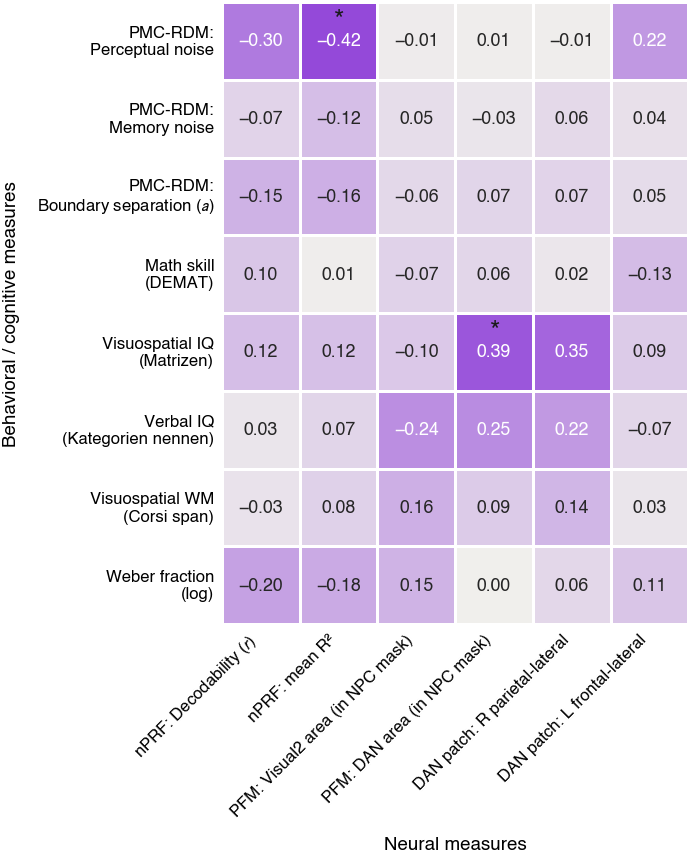

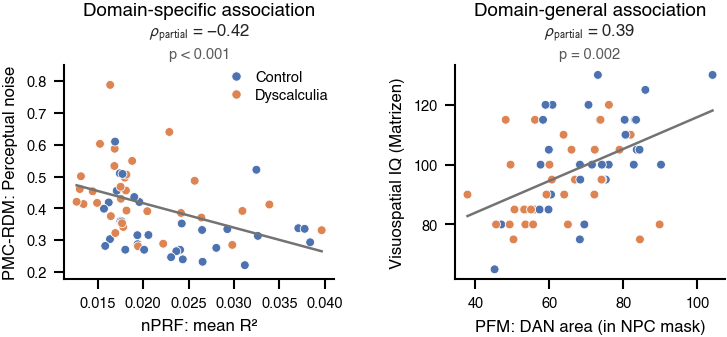

In [7]:
fig_a, ax_a = plt.subplots(figsize=(0.52 * len(neural_vars) + 3.2,
                                    0.52 * len(behav_vars) + 1.8))
draw_heatmap(ax_a, cbar_ax=None)
fig_a.tight_layout()
for d in OUT_DIRS:
    fig_a.savefig(op.join(d, f'combFig_crossmeasure_absR_behav-neural{suffix}.pdf'))

fig_b, axes_b = plt.subplots(1, len(sig_pairs), figsize=(2.55 * len(sig_pairs), 2.5))
for k, ((b, nv), ax) in enumerate(zip(sig_pairs, np.atleast_1d(axes_b))):
    draw_scatter(ax, b, nv, legend=(k == 0))
fig_b.tight_layout()
fig_b.subplots_adjust(wspace=0.45)
for d in OUT_DIRS:
    fig_b.savefig(op.join(d, f'combFig_crossmeasure_scatter{suffix}.pdf'))
print('standalone panels written')

## Combined figure — Fig. 4

Horizontal layout: the matrix on the left, the two surviving pairs stacked to its right.
The row labels are broken onto two lines (`wrap_label`) — they set the width of the left
margin, and that width is what the scatter column needs.


  perceptual_noise_sd x mean_R2: 1 point(s) off-scale (still in the fit and the stats)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


combFig4_behav-neural_group-removed_fdr_bh.pdf written to 2 dirs


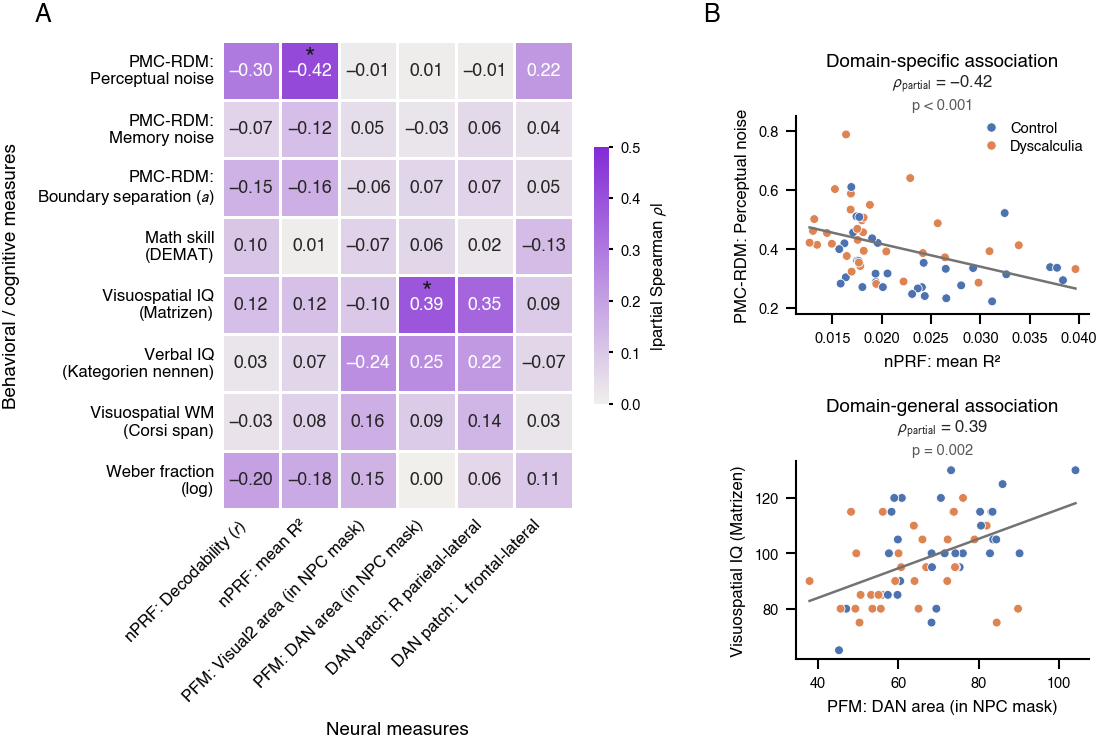

In [8]:
# Combined Fig. 4: matrix on the left, the two surviving pairs stacked to its right.
# Laid out in inches with add_axes rather than a GridSpec: the heatmap is square-aspect,
# so a GridSpec cell would only ever bound it and the real box would drift with the figure
# size, taking the colourbar and the panel letters out of alignment with it. Here every box
# is stated in inches, and MAT_W/MAT_H are exactly n_cells x CELL, so 'square' costs nothing.
FIG_W = 7.25                         # 7.25in = journal double-column width (house style)
CELL = 0.39                          # heatmap cell side
MAT_L, MAT_B = 1.32, 1.45            # left margin: two-line row labels; bottom: 45deg column labels
MAT_W, MAT_H = CELL * len(neural_vars), CELL * len(behav_vars)
MAT_T = MAT_B + MAT_H
FIG_H = MAT_T + 0.38                 # follows the matrix, + room for the panel letters

CBAR_GAP, CBAR_W, CBAR_FRAC = 0.14, 0.10, 0.55
SC_L, SC_W = 5.15, 1.95              # scatter column
# Generous margins around each scatter, not tight ones: every panel here is surrounded by
# text that belongs to a *different* panel (the matrix's column labels, the other scatter's
# heading), so the white space is what assigns each label to its own plot.
SC_HEAD, SC_XLAB = 0.50, 0.48        # above: heading/rho/p stack; below: the x label
SC_BOT = 0.45
SC_H = ((MAT_T - SC_HEAD) - SC_BOT - (SC_XLAB + SC_HEAD)) / 2

def _box(x, y, w, h):
    """inches -> figure fraction"""
    return [x / FIG_W, y / FIG_H, w / FIG_W, h / FIG_H]

fig = plt.figure(figsize=(FIG_W, FIG_H))
ax_mat = fig.add_axes(_box(MAT_L, MAT_B, MAT_W, MAT_H))
cax = fig.add_axes(_box(MAT_L + MAT_W + CBAR_GAP,
                        MAT_B + MAT_H * (1 - CBAR_FRAC) / 2,
                        CBAR_W, MAT_H * CBAR_FRAC))
ax_top = fig.add_axes(_box(SC_L, MAT_T - SC_HEAD - SC_H, SC_W, SC_H))
ax_bot = fig.add_axes(_box(SC_L, SC_BOT, SC_W, SC_H))

draw_heatmap(ax_mat, cbar_ax=cax)
cax.tick_params(labelsize=7, length=2)
cax.yaxis.label.set_size(8)

for k, ((b, nv), ax) in enumerate(zip(sig_pairs, [ax_top, ax_bot])):
    draw_scatter(ax, b, nv, legend=(k == 0))

# Letters in figure coordinates on one baseline per row -- offsetting from each axes would
# put them at different heights, since the panels differ in size and in how far their labels
# stick out (that is what add_panel_letter_fig exists for).
# Both scatters live under one letter B: they are two instances of the same thing (a pair
# that survived the matrix), and their headings already say which is which, so a second
# letter would imply a distinction that isn't there.
add_panel_letter_fig(fig, 'A', 0.01, (MAT_T + 0.10) / FIG_H)
add_panel_letter_fig(fig, 'B', (SC_L - 0.62) / FIG_W, (MAT_T + 0.10) / FIG_H)

for d in OUT_DIRS:
    fig.savefig(op.join(d, f'combFig4_behav-neural{suffix}.pdf'))
print(f'combFig4_behav-neural{suffix}.pdf written to {len(OUT_DIRS)} dirs')


## What survived, as a table

Handy for the figure caption / results text — every cell whose star is drawn, with the raw
and corrected p side by side so it stays clear which control produced which claim.

In [9]:
rows = []
for b in behav_vars:
    for nv in neural_vars:
        if pd.isna(pval.loc[b, nv]):
            continue
        rows.append({'behavioral': pretty_names.get(b, b),
                     'neural': pretty_names.get(nv, nv),
                     'rho': corr.loc[b, nv], '|rho|': abs_corr.loc[b, nv],
                     'n': int(n_obs.loc[b, nv]),
                     'p_raw': pval.loc[b, nv], f'p_{MC_METHOD}': pval_corrected.loc[b, nv]})

results = pd.DataFrame(rows).sort_values('p_raw').reset_index(drop=True)
results[results['p_raw'] < 0.05].round({'rho': 3, '|rho|': 3, 'p_raw': 4, f'p_{MC_METHOD}': 4})

,behavioral,neural,rho,|rho|,n,p_raw,p_fdr_bh
0,PMC-RDM: Perceptual noise,nPRF: mean R²,-0.420,0.420,65,0.0005,0.0260
1,Visuospatial IQ (Matrizen),PFM: DAN area (in NPC mask),0.389,0.389,65,0.0015,0.0361
2,Visuospatial IQ (Matrizen),DAN patch: R parietal-lateral,0.349,0.349,66,0.0044,0.0700
3,PMC-RDM: Perceptual noise,nPRF: Decodability ($r$),-0.297,0.297,65,0.0171,0.2049
4,Verbal IQ (Kategorien nennen),PFM: DAN area (in NPC mask),0.251,0.251,65,0.0453,0.4142


## Distinguishable but related? — raw vs partial, and specificity tests

<!-- SPECIFICITY_BLOCK -->

Two questions the matrix above does not answer on its own.

**Are the two components related?** Reported as raw *and* partial ρ side by side, because
partialling out group is the conservative direction here: if DD affects both measures, some
of what group removes is real evidence of coupling rather than confound. Note this cuts the
other way for the specificity test below, where partialling is clearly the right choice —
without it, any two measures that each differ by group correlate for that reason alone.

**Is each cross-level link specific to its own partner?** Williams' test for two dependent
correlations that share a variable (Steiger 1980), which accounts for the two neural measures
being correlated with each other. Computed on group-residualised ranks, so it tests the same
partial Spearman associations reported above, with a bootstrap CI on the difference.

The test is **one-tailed**, in the direction each association was predicted to take (`expect=`
per call, not read off the data): the claim is that a behavioural measure tracks its *own*
neural partner more closely than the other one, and a difference in the wrong direction would
not support it, so the alpha is not split between two tails. Same reasoning as the one-sided
group tests in Fig. 1B. Two intervals are reported because they answer different questions:
`CI low`/`CI high` is the usual two-sided 95% CI on the size of the difference, while
`bound (1-tailed 95%)` is the one matching the test — for the IQ/DAN row the two-sided CI
straddles zero (two-sided p = .053) while the one-tailed bound does not.


In [10]:
# SPECIFICITY_BLOCK: raw vs partial correlations, within- and cross-level
from scipy import stats as _st

PAIRS = [
    ('within behav', 'perceptual noise', 'memory noise', 'perceptual_noise_sd', 'memory_noise_sd'),
    ('within behav', 'perceptual noise', 'visuospatial IQ', 'perceptual_noise_sd', 'me'),
    ('within behav', 'memory noise', 'visuospatial IQ', 'memory_noise_sd', 'me'),
    ('within neural', 'nPRF mean R2', 'DAN area (NPC)', 'mean_R2', 'Dorsal-attention_size'),
    ('cross', 'perceptual noise', 'nPRF mean R2', 'perceptual_noise_sd', 'mean_R2'),
    ('cross', 'perceptual noise', 'DAN area (NPC)', 'perceptual_noise_sd', 'Dorsal-attention_size'),
    ('cross', 'visuospatial IQ', 'DAN area (NPC)', 'me', 'Dorsal-attention_size'),
    ('cross', 'visuospatial IQ', 'nPRF mean R2', 'me', 'mean_R2'),
]

rows = []
for level, la, lb, a, b in PAIRS:
    sub = df_bn[[a, b, 'group']].dropna()
    raw = _st.spearmanr(sub[a], sub[b])
    par = pingouin.partial_corr(data=sub, x=a, y=b, covar='group', method='spearman')
    rows.append({'level': level, 'measure A': la, 'measure B': lb,
                 'rho (raw)': round(raw.statistic, 3), 'p (raw)': round(raw.pvalue, 4),
                 'rho (partial)': round(par['r'].iloc[0], 3),
                 'p (partial)': round(par['p-val'].iloc[0], 4),
                 'N': len(sub)})

specificity_table = pd.DataFrame(rows)
for d in OUT_DIRS:
    specificity_table.to_csv(op.join(d, 'crossmeasure_raw-vs-partial.csv'), index=False)
specificity_table


,level,measure A,measure B,rho (raw),p (raw),rho (partial),p (partial),N
0,within behav,perceptual noise,memory noise,0.567,0.0000,0.430,0.0003,66
1,within behav,perceptual noise,visuospatial IQ,-0.189,0.1292,-0.070,0.5818,66
2,within behav,memory noise,visuospatial IQ,-0.254,0.0396,-0.095,0.4496,66
3,within neural,nPRF mean R2,DAN area (NPC),0.325,0.0089,0.248,0.0501,64
4,cross,perceptual noise,nPRF mean R2,-0.491,0.0000,-0.420,0.0005,65
5,cross,perceptual noise,DAN area (NPC),-0.145,0.2478,0.005,0.9687,65
6,cross,visuospatial IQ,DAN area (NPC),0.453,0.0001,0.389,0.0015,65
7,cross,visuospatial IQ,nPRF mean R2,0.194,0.1210,0.121,0.3427,65


In [11]:
# SPECIFICITY_BLOCK: Williams test — is each behavioural measure closer to its own neural partner?
from scipy import stats as _st

def _resid_ranks(sub, cols):
    """Partial Spearman == Pearson on group-residualised ranks."""
    G = np.c_[np.ones(len(sub)), sub['group'].values]
    return {c: (lambda y: y - G @ np.linalg.lstsq(G, y, rcond=None)[0])(_st.rankdata(sub[c].values))
            for c in cols}

EXPECTED_SIGN = {'positive': 1, 'negative': -1}


def _williams(r12, r13, r23, n, sign):
    """Compare dependent correlations r12 and r13 sharing variable 1 (Steiger 1980).

    **One-tailed.** The claim being tested is directional -- each behavioural measure tracks
    its *own* neural partner more closely than the other one -- and a difference in the wrong
    direction would not support it, so the whole alpha goes in the predicted direction rather
    than being split between two tails (the same reasoning as the one-sided group tests in
    Fig. 1B). `sign` is the a-priori sign of the own-partner association: with sign = -1 the
    prediction is r12 *below* r13, so it is the lower tail that counts. Passing it explicitly,
    rather than reading the direction off the data, is what keeps the tail a prediction.
    """
    det = 1 - r12**2 - r13**2 - r23**2 + 2 * r12 * r13 * r23
    rbar = (r12 + r13) / 2
    t = (r12 - r13) * np.sqrt(((n - 1) * (1 + r23)) /
                              ((2 * (n - 1) / (n - 3)) * det + rbar**2 * (1 - r23)**3))
    return t, n - 3, _st.t.sf(sign * t, n - 3)

def specificity_test(shared, own, other, expect, n_boot=10000, seed=0):
    """`expect`: the a-priori sign ('positive'/'negative') of the own-partner association."""
    sign = EXPECTED_SIGN[expect]
    sub = df_bn[[shared, own, other, 'group']].dropna()
    n = len(sub)
    R = _resid_ranks(sub, [shared, own, other])
    r12 = np.corrcoef(R[shared], R[own])[0, 1]
    r13 = np.corrcoef(R[shared], R[other])[0, 1]
    r23 = np.corrcoef(R[own], R[other])[0, 1]
    t, dfree, p = _williams(r12, r13, r23, n, sign)
    rng = np.random.default_rng(seed)
    diffs = [np.corrcoef(R[shared][s], R[own][s])[0, 1] - np.corrcoef(R[shared][s], R[other][s])[0, 1]
             for s in (rng.choice(n, n, replace=True) for _ in range(n_boot))]
    # Two-sided 95% CI, kept as the descriptive interval on the size of the difference --
    # it is not the interval that matches the one-tailed test, hence the separate bootstrap
    # p, which is the share of resamples landing on the null side of the predicted direction.
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    # ...and the bound that *does* match the one-tailed test, so a two-sided CI straddling
    # zero next to p < .05 reads as the two conventions it is, not as a contradiction
    bound = np.percentile(diffs, 5 if sign > 0 else 95)
    p_boot = float(np.mean(sign * np.asarray(diffs) <= 0))
    return {'behavioural': pretty_names.get(shared, shared),
            'own partner': pretty_names.get(own, own),
            'other': pretty_names.get(other, other),
            'rho own': round(r12, 3), 'rho other': round(r13, 3),
            'difference': round(r12 - r13, 3),
            'CI low': round(lo, 3), 'CI high': round(hi, 3),
            'bound (1-tailed 95%)': round(bound, 3),
            't': round(t, 2), 'df': dfree, 'p (1-tailed)': round(p, 4),
            'p boot (1-tailed)': round(p_boot, 4), 'N': n}

# expect= is the direction each association was predicted to take: more perceptual noise
# with *lower* nPRF R2, higher visuospatial IQ with *larger* DAN area.
williams_table = pd.DataFrame([
    specificity_test('perceptual_noise_sd', 'mean_R2', 'Dorsal-attention_size', expect='negative'),
    specificity_test('me', 'Dorsal-attention_size', 'mean_R2', expect='positive'),
])
for d in OUT_DIRS:
    williams_table.to_csv(op.join(d, 'crossmeasure_specificity_williams.csv'), index=False)
williams_table


,behavioural,own partner,other,rho own,rho other,difference,CI low,CI high,bound (1-tailed 95%),t,df,p (1-tailed),p boot (1-tailed),N
0,PMC-RDM: Perceptual noise,nPRF: mean R²,PFM: DAN area (in NPC mask),-0.408,-0.002,-0.406,-0.704,-0.117,-0.161,-2.84,61,0.0031,0.0030,64
1,Visuospatial IQ (Matrizen),PFM: DAN area (in NPC mask),nPRF: mean R²,0.391,0.104,0.287,-0.014,0.568,0.037,1.97,61,0.0265,0.0311,64
